In [1]:
import sys
sys.path.append('../../../../work_package_1')

import single_crystal_analysis
from single_crystal_analysis.imports import *

#plt.rcParams['text.usetex'] = True

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'

# 1. Plotting stress-strain curves from surrogate training runs and single crystal copper tensile test

In [2]:
phenopowerlaw_params_file = '/Users/user/Documents/simulations/csf_sims/work_package_1/single_crystal_final/phenopowerlaw_surrogate_training_data/strain_rate_3e-3/training_data/phenopowerlaw_single_crystal_lhs_correct_strain_rate_2026-03-13_110951_parameters.npy'
phenopowerlaw_outputs_file = '/Users/user/Documents/simulations/csf_sims/work_package_1/single_crystal_final/phenopowerlaw_surrogate_training_data/strain_rate_3e-3/training_data/phenopowerlaw_single_crystal_lhs_correct_strain_rate_2026-03-13_110951_outputs.npy' 

In [3]:
strain_incs = np.linspace(0.0025,0.137,100)

In [4]:
# Load in experimental data for [111] loading from Takeuchi
exp_data_file = '/Users/user/Documents/extracted_data/single_crystal_copper_tensile_tests/takeuchi_111_copper_exp_elongation.csv'
exp_true_strain, exp_true_stress = single_crystal_analysis.load_exp_data(exp_data_file, true_data=False)

In [5]:
pheno_params, pheno_outputs = single_crystal_analysis.load_LHS_outputs(phenopowerlaw_outputs_file, phenopowerlaw_params_file, filter = False)

(0.0, 0.137)

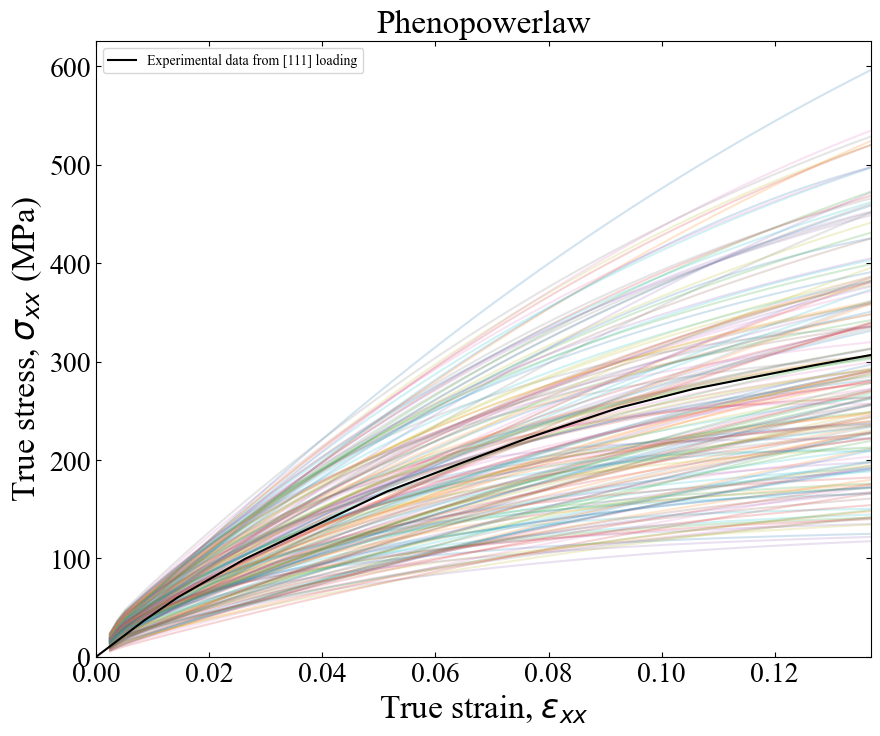

In [6]:
#Plot stress-strain curves from training data and reference curve
%matplotlib inline
single_crystal_analysis.plot_LHS_sample_stress_strain_curves(strain_incs, pheno_outputs, model_type = 'Phenopowerlaw')
plt.plot(exp_true_strain, exp_true_stress, 'k', label = 'Experimental data from [111] loading')
plt.legend(loc = 'upper left')
plt.ylim(0)
plt.xlim(0)

In [7]:
len(pheno_outputs)

182

# Training distributions

In [8]:
N_inputs = pheno_params.shape[1]

fitting_param_names = [r'$\it{a}$', r'$\it{\xi}_{0}$', r'$\it{\xi}_{\infty}$', r'$\it{h}_{0}^{\it{sl-sl}}$']

Text(0.5, 0.98, 'Training Data Distributions')

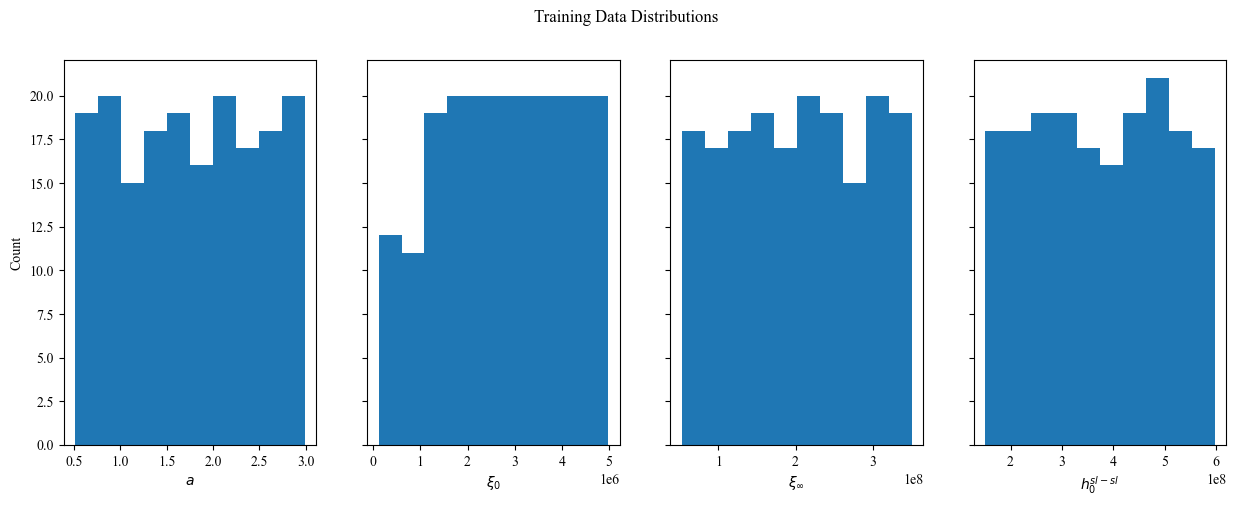

In [9]:
fig_train_dist,axs_train_dist=plt.subplots(1,N_inputs,sharey=True,figsize=(15,5))

for i in range(N_inputs):

    axs_train_dist[i].hist(pheno_params[:,i])
    axs_train_dist[i].set_xlabel(fitting_param_names[i])

axs_train_dist[0].set_ylabel('Count')
fig_train_dist.suptitle('Training Data Distributions')

# 2. Surrogate model building (Gaussian Process Regression)

In [10]:
from surrogatetools import *

In [11]:
pheno_params = np.array(pheno_params)
pheno_outputs = np.array(pheno_outputs)
X_train = pheno_params
Y_train = pheno_outputs

In [12]:
surrogate = Surrogate(X_train, Y_train, parameter_names = fitting_param_names)
surrogate.scale_data()

In [13]:
surrogate.parameter_range

array([[5.12333270e-01, 2.99194152e+00],
       [1.14414733e+05, 4.98254735e+06],
       [5.25331462e+07, 3.49871205e+08],
       [1.50020145e+08, 5.97969318e+08]])

In [14]:
surrogate.build_model(n_restarts_optimizer=5,
                        cross_validate=True,
                        scoring='r2',
                        normalize_y=True)

/opt/homebrew/Cellar/micromamba/2.0.8/envs/pymc-env/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Cross validation score:  [1. 1. 1. 1. 1.]


In [15]:
surrogate.model.kernel_

15.8**2 * Matern(length_scale=[21.8, 20.1, 10.4, 24.2], nu=2.5) + 0.529**2

Global sensitivity analysis

In [16]:
sobol = surrogate.generate_sobol(n = 2**14)

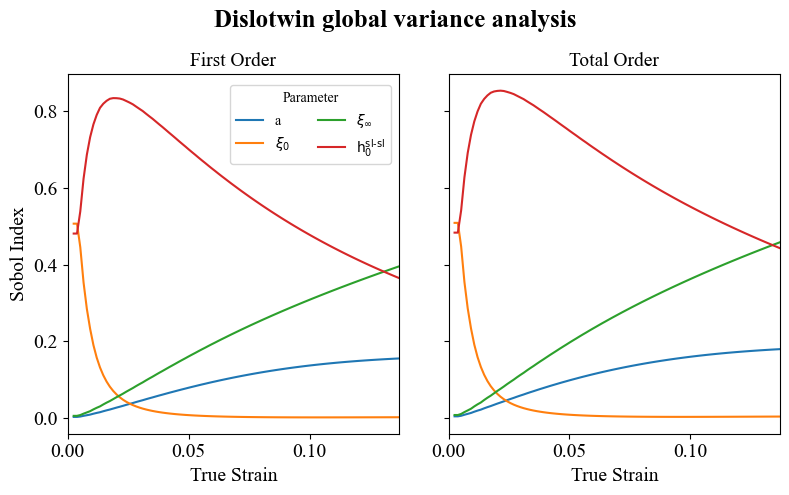

In [17]:
fitting_params = ['a', r'$\xi_{0}$', r'$\xi_{\infty}$', r'$\text{h}_{0}^{\text{sl-sl}}$']

fig,axs=plt.subplots(1,2,sharey=True,figsize=(8,5),sharex=True)

for i in range(len(fitting_params)):

    axs[0].plot(strain_incs,sobol.first_order[:,i],label=fitting_params[i]) #label=fitting_param_names[i])
    axs[1].plot(strain_incs,sobol.total_order[:,i],label=fitting_params[i]) #label=fitting_param_names[i])


#Graph stuff
fig.suptitle('Dislotwin global variance analysis',weight='bold', fontsize = 18)
#fig.suptitle('Polycrystalline copper variance analysis',weight='bold', fontsize = 18)

axs[0].legend(title='Parameter', loc = (0.49,0.75), ncol=2)
axs[0].set_ylabel('Sobol Index', fontsize=14)
axs[0].set_xlabel('True Strain', fontsize=14)
axs[1].set_xlabel('True Strain', fontsize=14)
#axs[0].set_xscale('log')
#axs[1].set_xscale('log')
axs[0].set_xlim(0, max(strain_incs))
axs[1].set_xlim(0, max(strain_incs))
#axs[0].set_ylim(1e-3)
#axs[1].set_ylim(1e-3)



axs[0].set_title('First Order', fontsize=14)
axs[1].set_title('Total Order', fontsize=14)
axs[0].tick_params(labelsize=14)
axs[0].tick_params(labelsize=14)
axs[1].tick_params(labelsize=14)
axs[1].tick_params(labelsize=14)

fig.tight_layout()

RMSE Sobol' indices

In [18]:
interp_exp_stress = single_crystal_analysis.interp_exp_data(exp_true_strain, exp_true_stress, strain_incs)

#type(Y_train), type(interp_exp_stress)
RMSE_train = []
for i in range(len(Y_train)):
    RMSE = np.sqrt(np.mean((Y_train[i]-interp_exp_stress)**2))
    RMSE_train.append(RMSE)

RMSE_train = np.array(RMSE_train).reshape((-1,1))

print(X_train.shape, RMSE_train.shape)

surrogate_rmse = Surrogate(X_train, RMSE_train, parameter_names = fitting_param_names)
surrogate_rmse.scale_data()

(182, 4) (182, 1)


In [20]:
surrogate_rmse.build_model(n_restarts_optimizer=5,
                        cross_validate=True,
                        scoring='r2',
                        normalize_y=True)

Cross validation score:  [0.97 0.91 0.99 0.98 0.97]


In [21]:
sobol_rmse = surrogate_rmse.generate_sobol(n=2**14)

(np.float64(0.3906913158773526), np.float64(1.686322922468209))

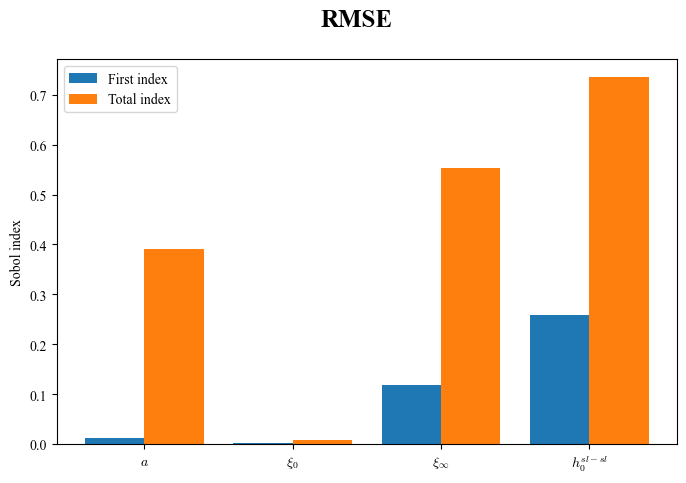

In [22]:
w, x = 0.4, np.arange(len(fitting_params))

fig_sob, axs_sob = plt.subplots(1,1,figsize=(8,5))

fig_sob.suptitle('RMSE',weight='bold', fontsize = 18)
axs_sob.bar(x-w/2, sobol_rmse.first_order, width = w, label = 'First index')
axs_sob.bar(x+w/2, sobol_rmse.total_order, width = w, label = 'Total index')
axs_sob.set_xticks(x)
axs_sob.set_xticklabels(fitting_param_names, math_fontfamily = 'cm')
axs_sob.set_ylabel('Sobol index')
axs_sob.set_ylim(0)
plt.legend()

np.sum(sobol_rmse.first_order), np.sum(sobol_rmse.total_order)

In [23]:
from scipy.stats import qmc
rng = np.random.default_rng()

sample = qmc.Sobol(d=len(fitting_params), seed=rng).random(2**14)
sample = qmc.scale(
    sample=sample,
    l_bounds=[surrogate.parameter_range[0][0], surrogate.parameter_range[1][0], surrogate.parameter_range[2][0], surrogate.parameter_range[3][0]],
    u_bounds=[surrogate.parameter_range[0][1], surrogate.parameter_range[1][1], surrogate.parameter_range[2][1], surrogate.parameter_range[3][1]]
)

output = surrogate_rmse.make_prediction_sobol(sample.T)

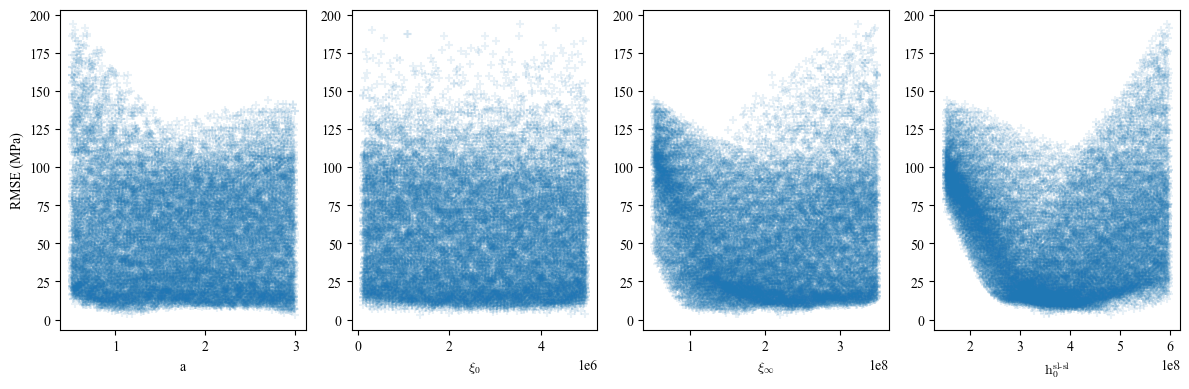

In [24]:
fig_sob_samp, ax_sob_samp = plt.subplots(1, len(fitting_params), figsize=(12, 4))
for i in range(len(fitting_params)):
    xi = sample[:, i]
    ax_sob_samp[i].scatter(xi, output, marker='+', alpha = 0.1)
    ax_sob_samp[i].set_xlabel(fitting_params[i], math_fontfamily = 'cm')
ax_sob_samp[0].set_ylabel('RMSE (MPa)')
plt.tight_layout()
plt.show()

# 3. Deterministic fit using surrogate model

In [25]:
error = 0.01*interp_exp_stress #np.linspace(5, 0, len(interp_exp_stress)) + 0.01*interp_exp_stress

# Ideally want an error that captures the initial uncertainty around the yield point (given the nature of the experimental data used in single crystal copper studies)
# and the approximate exp error of 1% stress value at higher strains.

res = surrogate.fit(Y_actual = interp_exp_stress,
                    Y_error = error,
                    iters = 5,
                    n = 250,
                    use_std = True)

print(res)

 message: Optimization terminated successfully.
 success: True
     fun: 989.6686316089712
    funl: [ 9.897e+02  1.029e+03 ...  2.264e+05  2.455e+05]
       x: [ 8.816e-01  1.331e+06  1.269e+08  3.740e+08]
      xl: [[ 8.816e-01  1.331e+06  1.269e+08  3.740e+08]
           [ 1.560e+00  1.331e+06  2.012e+08  3.740e+08]
           ...
           [ 1.752e+00  1.331e+06  8.970e+07  2.060e+08]
           [ 1.752e+00  1.145e+05  8.970e+07  2.060e+08]]
     nit: 5
    nfev: 14795
   nlfev: 13529
   nljev: 1140
   nlhev: 0


In [26]:
Y_prediction, Y_error = surrogate.make_prediction(res.x.reshape(1,-1), return_std=True)

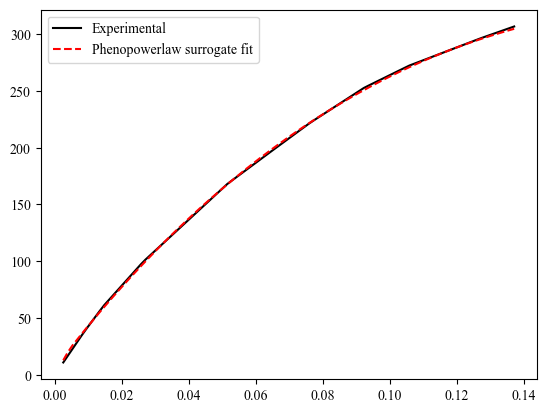

In [27]:
plt.plot(strain_incs, interp_exp_stress, 'k', label = 'Experimental')
plt.plot(strain_incs, Y_prediction[0], 'r--',label = 'Phenopowerlaw surrogate fit')
plt.legend()

In [28]:
# Regression coefficient
import sklearn
score = sklearn.metrics.r2_score(interp_exp_stress,Y_prediction[0])

print('r2 score =',np.round(score,6))

r2 score = 0.999825


Analysing deterministic fit

In [29]:
def model_error(x_exp,y_exp,x_sim,y_sim,nsamples=100):

        minval,maxval = max(min(x_exp),min(x_sim)), min(max(x_exp),max(x_sim))

        spacing = np.linspace(minval,maxval,nsamples)

        sample_exp = scipy.interpolate.interp1d(x=x_exp,y=y_exp)
    
        sample_sim = scipy.interpolate.interp1d(x=x_sim,y=y_sim)

        loss = np.sum(np.power(sample_exp(spacing) - sample_sim(spacing),2))

        return loss

In [30]:
model_error(exp_true_strain, exp_true_stress, strain_incs, Y_prediction[0])

np.float64(126.22056985753242)

In [31]:
# RMSE
np.sqrt(np.mean((interp_exp_stress-Y_prediction[0])**2))

np.float64(1.1234792826640483)

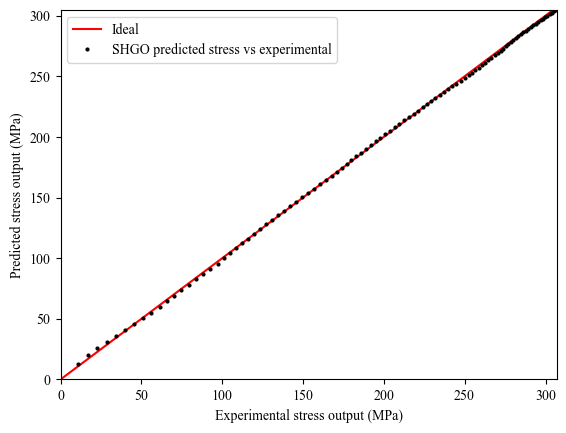

In [32]:
plt.axline([0,0], slope = 1, color = 'r', label = 'Ideal')
plt.plot(interp_exp_stress, Y_prediction[0], 'ko', markersize = 2, label = 'SHGO predicted stress vs experimental')
plt.xlabel('Experimental stress output (MPa)')
plt.ylabel('Predicted stress output (MPa)')
plt.xlim(0, max(interp_exp_stress))
plt.ylim(0, max(Y_prediction[0]))
plt.legend()

# 3b Surrogate test data

In [33]:
test_params = np.load('./test_data/phenopowerlaw_single_crystal_lhs_correct_strain_rate_test_2026-03-13_162403_parameters.npy')
test_outputs = np.load('./test_data/phenopowerlaw_single_crystal_lhs_correct_strain_rate_test_2026-03-13_162403_outputs.npy')

In [34]:
Y_test_prediction, Y_test_error = surrogate.make_prediction(test_params, return_std=True)

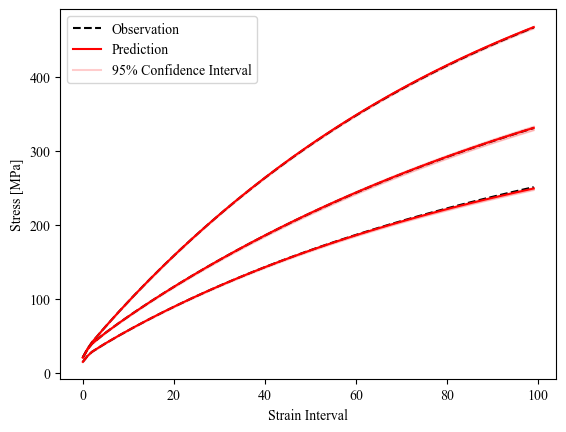

In [37]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

random_samples = np.random.randint(low=0,high=len(test_params), size=3)

for idx in random_samples:
    plt.fill_between(range(len(Y_test_prediction[idx])), Y_test_prediction[idx]+2*Y_test_error[idx],Y_test_prediction[idx]-2*Y_test_error[idx],alpha=0.2,color='r')
    plt.plot(test_outputs[idx],color='k',linestyle='dashed')
    plt.plot(Y_test_prediction[idx],color='r')

plt.xlabel('Strain Interval')
plt.ylabel('Stress [MPa]')

legend_elements = [Line2D([0], [0], color='k', label='Observation',ls='dashed'),
                   Line2D([0], [0], color='r', label='Prediction'),
                   Line2D([0], [0], color='r', label='95% Confidence Interval', alpha=0.2)]#lw=5,alpha=0.2)]

plt.legend(handles=legend_elements)

# 4. Bayesian Inference from MCMC sampling

In [42]:
new_inference_data = surrogate.perfom_inference(Y_actual=interp_exp_stress,
                                            Y_error=error,
                                            draws=500_000,
                                            tune=500_000,
                                            chains=4,
                                            cores=4,
                                            return_inferencedata=True,
                                            initval=res.x,
                                            use_std=True
                                            )

Multiprocess sampling (4 chains in 4 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [$\it{a}$, $\it{\xi}_{0}$, $\it{\xi}_{\infty}$, $\it{h}_{0}^{\it{sl-sl}}$]
INFO:pymc.sampling.mcmc:DEMetropolisZ: [$\it{a}$, $\it{\xi}_{0}$, $\it{\xi}_{\infty}$, $\it{h}_{0}^{\it{sl-sl}}$]


Output()

Sampling 4 chains for 500_000 tune and 500_000 draw iterations (2_000_000 + 2_000_000 draws total) took 197 seconds.
INFO:pymc.sampling.mcmc:Sampling 4 chains for 500_000 tune and 500_000 draw iterations (2_000_000 + 2_000_000 draws total) took 197 seconds.


In [43]:
import arviz as az

az.summary(new_inference_data)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
$\it{a}$,2.746000e+00,0.075,2.606000e+00,2.882000e+00,0.000,0.001,32035.0,29674.0,1.0
$\it{\xi}_{0}$,2.333490e+05,40853.919,1.567389e+05,3.102051e+05,185.123,139.697,46358.0,39933.0,1.0
$\it{\xi}_{\infty}$,2.398319e+08,3978661.699,2.322209e+08,2.470119e+08,22172.823,28689.564,37432.0,29946.0,1.0
$\it{h}_{0}^{\it{sl-sl}}$,4.222679e+08,2073260.339,4.183011e+08,4.261035e+08,9021.454,6058.948,52623.0,68309.0,1.0


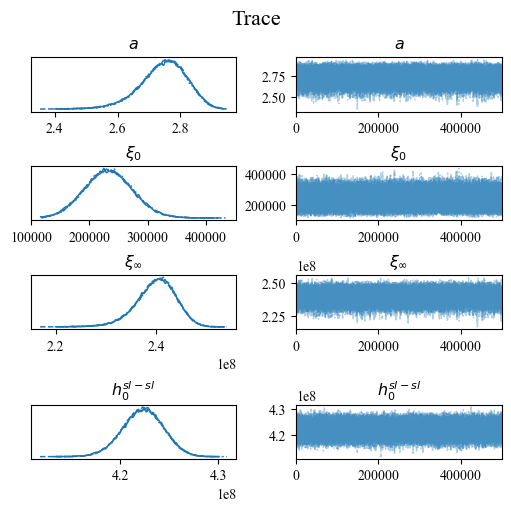

In [44]:
axes = az.plot_trace(
    data=new_inference_data,
    compact=True,
    backend_kwargs={"figsize": (12, 9), "layout": "constrained"},
)
plt.gcf().suptitle("Trace", fontsize=16)
plt.gcf().set_figwidth(5)
plt.gcf().set_figheight(5)

In [45]:
new_inference_data.to_netcdf('phenopowerlaw_inference_strain_rate_3e-3_500k_MCMC_samples.nc')

'phenopowerlaw_inference_strain_rate_3e-3_500k_MCMC_samples.nc'

In [ ]:
#Importing inference data from 50k MCMC samples
import arviz as az
inference_data = az.from_netcdf('phenopowerlaw_inference_strain_rate_3e-3.nc')

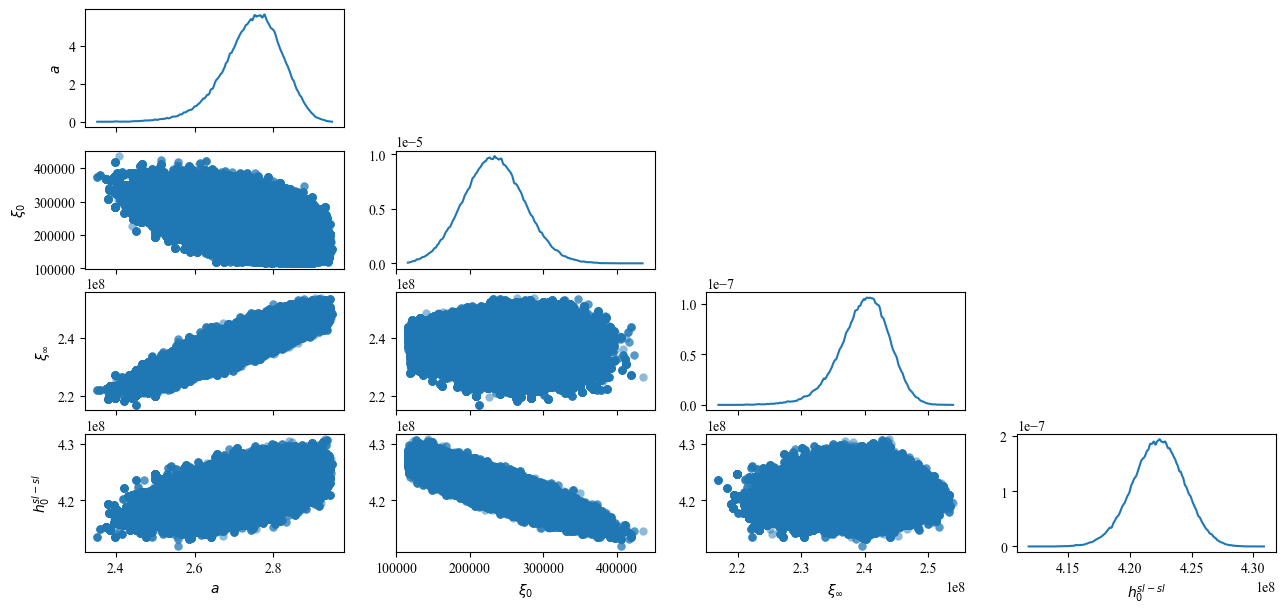

In [47]:
import arviz_plots as azp

pc = azp.plot_pair(
    new_inference_data,
    var_names=fitting_param_names,
    backend="matplotlib",
)
pc
#plt.savefig('phenopowerlaw_pancake_plots_3e-3_strain_rate.png', dpi = 800)

In [49]:
surrogate.parameter_names

['$\\it{a}$',
 '$\\it{\\xi}_{0}$',
 '$\\it{\\xi}_{\\infty}$',
 '$\\it{h}_{0}^{\\it{sl-sl}}$']

In [51]:
posteriors = np.array([np.array(new_inference_data.posterior[name]).flatten() for name in surrogate.parameter_names]).T

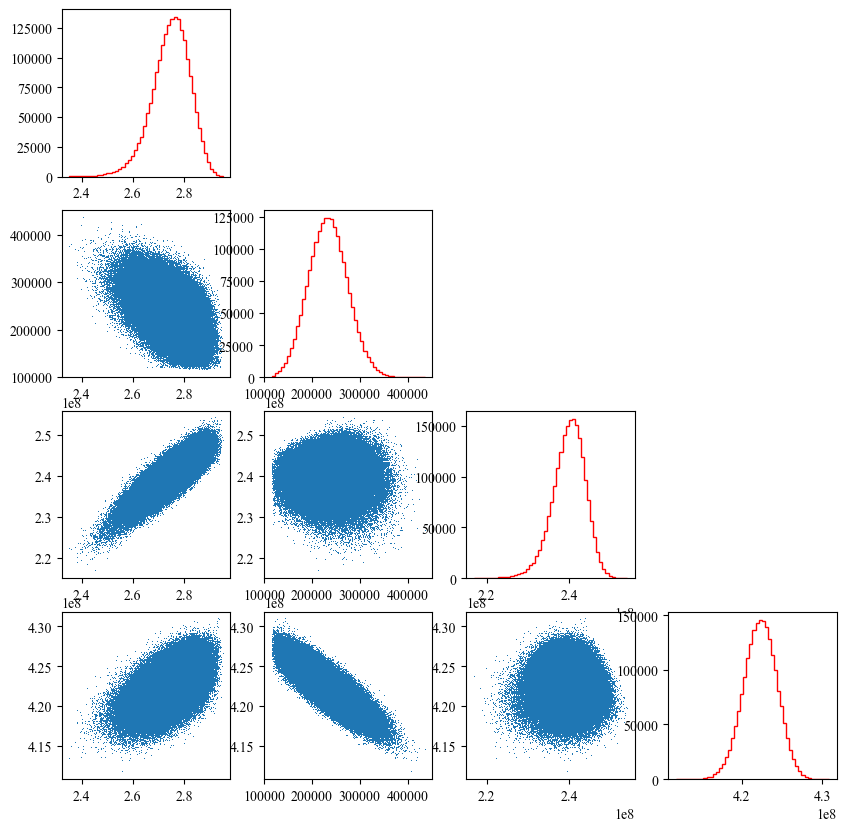

In [52]:
fig_egg, ax_egg = plt.subplots(len(fitting_param_names), len(fitting_param_names), figsize = (10,10))

for i in range(len(fitting_param_names)):
    for j in range(len(fitting_param_names)):
        if i >= j:
            if i==j:
                ax_egg[i][j].hist(posteriors[:,i], bins = 50, edgecolor = 'red', histtype = 'step')
            
                
            else:
                ax_egg[i][j].plot(posteriors[:,j], posteriors[:,i], marker = ',', ls = 'None')
        elif i < j:
            fig_egg.delaxes(ax_egg[i][j])


Posterior extraction

In [53]:
X_posterior = np.array([np.array(new_inference_data.posterior[x]).flatten() for x in surrogate.parameter_names]).T

X_mode = np.array([scipy.stats.mode(X_posterior[:,i])[0] for i in range(len(fitting_params))])
X_mean = np.array([np.mean(X_posterior[:,i]) for i in range(len(fitting_params))])
X_std = np.array([np.std(X_posterior[:,i]) for i in range(len(fitting_params))])

In [54]:
print(X_mode)
for i in range(len(X_mode)):
    print(X_mode[i])

[2.40118348e+00 3.31356586e+05 2.21327476e+08 4.17725151e+08]
2.401183475519772
331356.5857544518
221327475.69829813
417725150.79269505


In [55]:
print(X_mean)
for i in range(len(X_mean)):
    print(X_mean[i])

[2.74571423e+00 2.33348963e+05 2.39831935e+08 4.22267930e+08]
2.745714234238173
233348.96250133723
239831934.92240456
422267929.9856951


In [56]:
print((X_std/X_mode)*100)
print((X_std/X_mean)*100)

[ 3.1033934  12.32928829  1.79763524  0.49632152]
[ 2.71398125 17.50764533  1.658937    0.49098207]


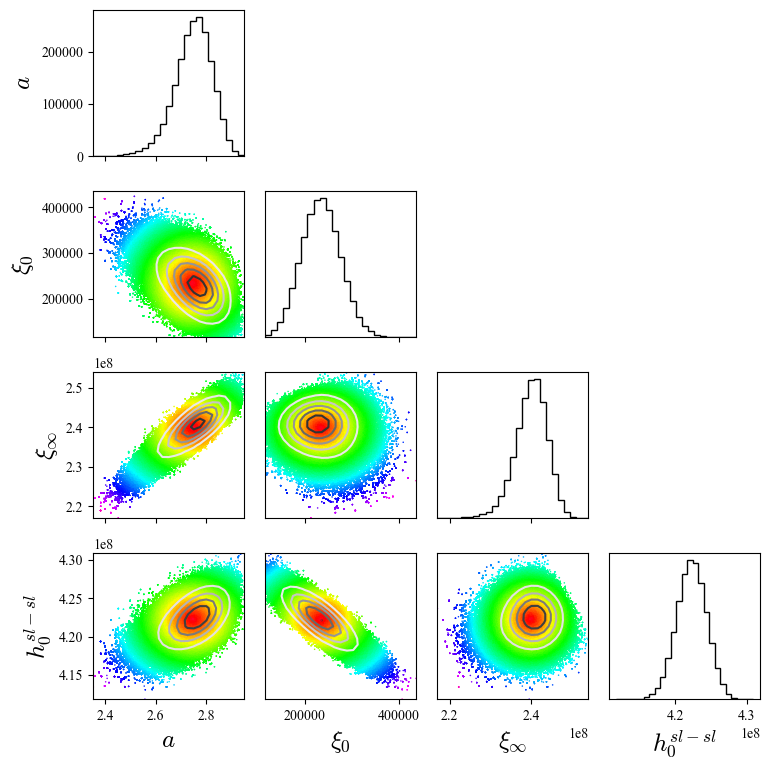

In [67]:
fig_galaxy,ax_galaxy=plt.subplots(len(X_posterior[0]),len(X_posterior[0]),figsize=(7.8,7.8), sharex='col')

for i in range(len(fitting_param_names)):

    for j in range(len(fitting_param_names)):

        if i==j:

            if j < 2:

                ax_galaxy[j,i].hist(X_posterior[:,j],bins=25, edgecolor = 'k', histtype = 'step')
            else:
                ax_galaxy[j,i].hist(X_posterior[:,j],bins=25, edgecolor = 'k', histtype = 'step')

        else:
            counts,ybins,xbins,image  = ax_galaxy[j,i].hist2d(X_posterior[:,i],X_posterior[:,j],bins=25,cmap='binary')#,norm='log')
            ax_galaxy[j,i].clear()
            
            error = np.sqrt(((X_posterior[:,i] - X_mean[i])/(X_std[i]))**2+((X_posterior[:,j]- X_mean[j])/(X_std[j]))**2)
            
            ax_galaxy[j,i].scatter(X_posterior[:,i],X_posterior[:,j],lw=0,ls='-',marker='.',s=5.0,c = error, cmap='gist_rainbow')

            counts = scipy.ndimage.gaussian_filter(counts, sigma=1.0)

            ax_galaxy[i,j].contour(counts,extent=[xbins.min(),xbins.max(),ybins.min(),ybins.max()],cmap='Greys',antialiased=True,levels=5)

        if j > i:

            fig_galaxy.delaxes(ax_galaxy[i,j])

        if j > 0:
            ax_galaxy[i,j].set_yticks([])

        if j < 2:
            pass
            #ax[i,j].set_xlim(-0.5,0.5)

        if j==0:
            ax_galaxy[i,j].set_ylabel(fitting_param_names[i], math_fontfamily = 'cm', fontsize = 18)

        if i==len(X_posterior[0])-1:
            ax_galaxy[i,j].set_xlabel(fitting_param_names[j], math_fontfamily = 'cm', fontsize = 18)
        
        else:            
            #ax[i,j].set_xlim(0.5,1.0)
            pass

fig_galaxy.tight_layout()

Local sensitivity analysis

In [59]:
surrogate.parameter_mean = X_mode
surrogate.parameter_std = X_std

In [60]:
local_sobol = surrogate.generate_sobol(n=2**10, use_fit=True)
boot = local_sobol.bootstrap()

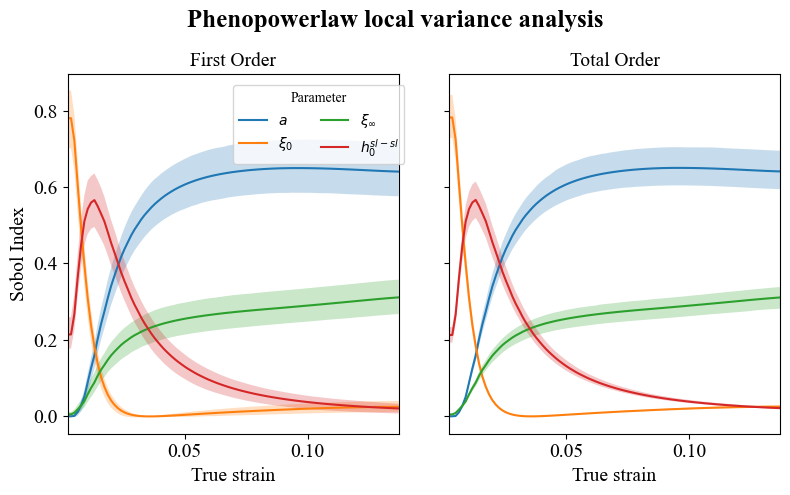

In [61]:
fig2,axs2=plt.subplots(1,2,sharey=True,figsize=(8,5),sharex=True)

for i in range(len(fitting_param_names)):

    axs2[0].fill_between(x=strain_incs,
                    y1=boot.first_order.confidence_interval.low[:,i],
                    y2=boot.first_order.confidence_interval.high[:,i],
                    alpha=0.25)
    axs2[1].fill_between(x=strain_incs,
                    y1=boot.total_order.confidence_interval.low[:,i],
                    y2=boot.total_order.confidence_interval.high[:,i],
                    alpha=0.25)
    
    axs2[0].plot(strain_incs,local_sobol.first_order[:,i],label=fitting_param_names[i]) #label=fitting_param_names[i])
    axs2[1].plot(strain_incs,local_sobol.total_order[:,i],label=fitting_param_names[i]) #label=fitting_param_names[i])   

#Graph stuff
fig2.suptitle('Phenopowerlaw local variance analysis',weight='bold', fontsize = 18)
#fig.suptitle('Polycrystalline copper variance analysis',weight='bold', fontsize = 18)

axs2[0].legend(title='Parameter', loc = (0.5, 0.75), ncol = 2)
axs2[0].set_ylabel('Sobol Index', fontsize=14)
#axs[0].set_yscale('log')
axs2[0].set_xlabel('True strain', fontsize=14)
axs2[1].set_xlabel('True strain', fontsize=14)
#axs[0].set_xscale('log')
#axs[1].set_xscale('log')
axs2[0].set_xlim(min(strain_incs), max(strain_incs))
axs2[1].set_xlim(min(strain_incs), max(strain_incs))
#axs[0].set_ylim(1e-3)
#axs[1].set_ylim(1e-3)



axs2[0].set_title('First Order', fontsize=14)
axs2[1].set_title('Total Order', fontsize=14)
axs2[0].tick_params(labelsize=14)
axs2[0].tick_params(labelsize=14)
axs2[1].tick_params(labelsize=14)
axs2[1].tick_params(labelsize=14)
#axs[0].set_yscale('log')
#axs[1].set_yscale('log')

fig2.tight_layout()

#plt.savefig('phenopowerlaw_local_sobol_3e-3_strain_rate.png', dpi=800)

np.float64(1.6853440308797627)

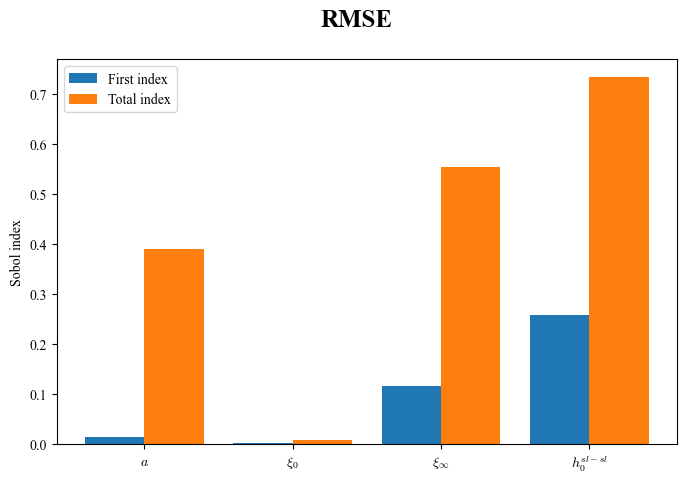

In [62]:
surrogate_rmse.parameter_mean = X_mode
surrogate_rmse.parameter_std = X_std

local_sobol_rmse = surrogate_rmse.generate_sobol(n = 2**14)

fig_local_sob, axs_local_sob = plt.subplots(1,1,figsize=(8,5))

fig_local_sob.suptitle('RMSE',weight='bold', fontsize = 18)
axs_local_sob.bar(x-w/2, local_sobol_rmse.first_order, width = w, label = 'First index')
axs_local_sob.bar(x+w/2, local_sobol_rmse.total_order, width = w, label = 'Total index')
axs_local_sob.set_xticks(x)
axs_local_sob.set_xticklabels(fitting_param_names, math_fontfamily = 'cm')
axs_local_sob.set_ylabel('Sobol index')
axs_local_sob.set_ylim(0)
plt.legend()

np.sum(local_sobol_rmse.total_order)
#plt.savefig('phenopowerlaw_local_sobol_rmse_3e-3_strain_rate.png', dpi=800)

In [63]:
from scipy.stats import qmc
rng = np.random.default_rng()
local_sample = qmc.Sobol(d=len(fitting_param_names), seed=rng).random(2**14)
local_sample = qmc.scale(
    sample=local_sample,
    l_bounds=[surrogate_rmse.parameter_mean[0]-2*surrogate_rmse.parameter_std[0],
              surrogate_rmse.parameter_mean[1]-2*surrogate_rmse.parameter_std[1],
              surrogate_rmse.parameter_mean[2]-2*surrogate_rmse.parameter_std[2],
              surrogate_rmse.parameter_mean[3]-2*surrogate_rmse.parameter_std[3]],
    u_bounds=[surrogate_rmse.parameter_mean[0]+2*surrogate_rmse.parameter_std[0],
              surrogate_rmse.parameter_mean[1]+2*surrogate_rmse.parameter_std[1],
              surrogate_rmse.parameter_mean[2]+2*surrogate_rmse.parameter_std[2],
              surrogate_rmse.parameter_mean[3]+2*surrogate_rmse.parameter_std[3]]
)

local_output = surrogate_rmse.make_prediction_sobol(local_sample.T)

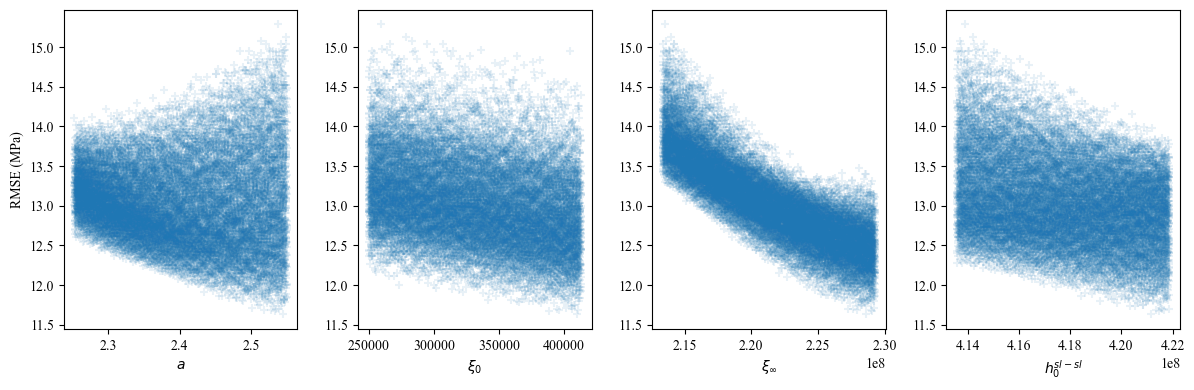

In [64]:
fig_local_sob_samp, ax_local_sob_samp = plt.subplots(1, len(fitting_param_names), figsize=(12, 4))
for i in range(len(fitting_param_names)):
    local_xi = local_sample[:, i]
    ax_local_sob_samp[i].scatter(local_xi, local_output, marker='+', alpha = 0.1)
    ax_local_sob_samp[i].set_xlabel(fitting_param_names[i])
ax_local_sob_samp[0].set_ylabel('RMSE (MPa)')
plt.tight_layout()
#plt.savefig('phenopowerlaw_local_sobol_samples_3e-3_strain_rate.png', dpi=800)
plt.show()

# 5. Surrogate prediction vs synthetic stress-strain curve and direct simulation using calibrated parameters

In [65]:
# Loading in direct simulation with calibrated parameter set
direct_pheno_strain, direct_pheno_stress = single_crystal_analysis.direct_stress_strain_data('./calibrated_sims/phenopowerlaw_calibrated_params_correct_strain_rate_2026-03-13_232420')

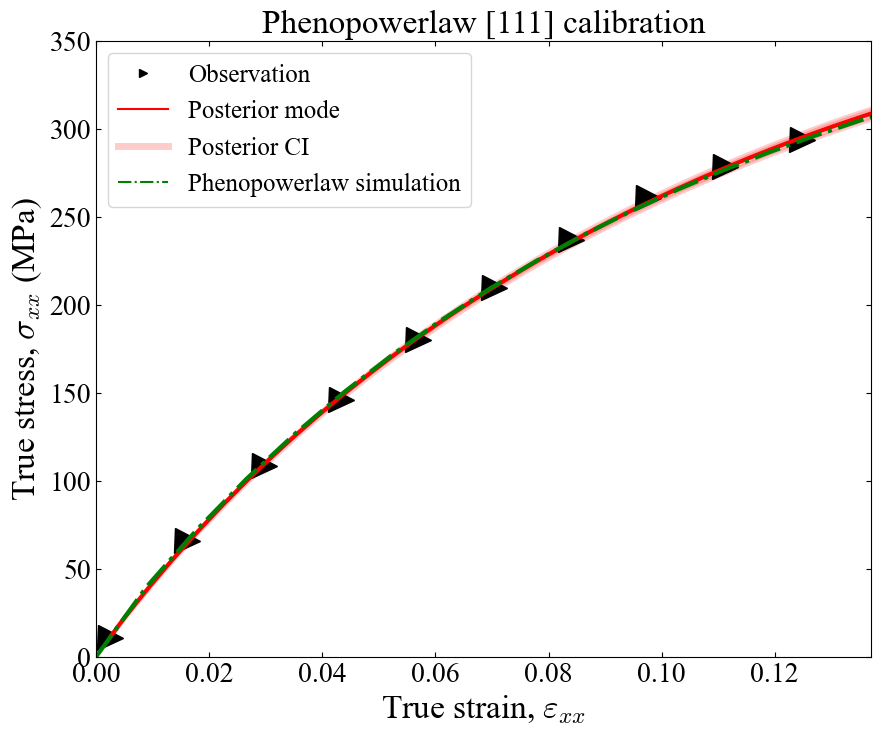

In [66]:
from matplotlib.lines import Line2D

y_opt, y_opt_err = surrogate.make_prediction(X_mode.reshape(1, -1), return_std=True)

fig_unc = plt.figure(figsize = (10,8))
ax_unc = fig_unc.add_subplot(1,1,1)

ax_unc.set_title('Phenopowerlaw [111] calibration', fontsize = 24)

ax_unc.plot(strain_incs[::10], interp_exp_stress[::10],color='k',ls='None', marker = '>', markersize = 18)#lw=3)
ax_unc.plot(strain_incs, y_opt[0],color='r',ls='-', lw=3)
#ax_unc.fill_between(strain_incs,interp_exp_stress+2*error,interp_exp_stress-2*error,color='k',alpha=0.2) #range(len(interp_exp_stress))
ax_unc.fill_between(strain_incs,y_opt[0]+2*y_opt_err[0],y_opt[0]-2*y_opt_err[0],color='r', lw = 3, alpha=0.2) #range(len(y_opt[0]))
ax_unc.plot(direct_pheno_strain, direct_pheno_stress, color='g', ls = '-.', lw=3)

legend_elements = [Line2D([0], [0], color='k', label='Observation',marker = '>', ls = 'None'),
                   #Line2D([0], [0], color='k', label='Observation CI ', lw=5,alpha=0.2),
                   Line2D([0], [0], color='r', label='Posterior mode'),
                   Line2D([0], [0], color='r', label='Posterior CI ', lw=5,alpha=0.2),
                   Line2D([0], [0], color='g', label='Phenopowerlaw simulation', ls='dashdot'),
                    ]

ax_unc.set_xlim(0, max(strain_incs))
ax_unc.set_ylim(0,350)
ax_unc.set_xlabel(r'True strain, $\varepsilon_{xx}$', fontsize = 24, math_fontfamily = 'cm')
ax_unc.set_ylabel(r'True stress, $\sigma_{xx}$ (MPa)', fontsize = 24, math_fontfamily = 'cm')
ax_unc.tick_params(direction = 'in', top = True, right = True, labelsize = 20)

ax_unc.legend(handles=legend_elements, ncol=1, fontsize = 18)
#plt.savefig('phenopowerlaw_calibrated_stress-strain_with_direct_sim_3e-3_strain_rate.png', dpi=800)

In [177]:
posterior_score = sklearn.metrics.r2_score(interp_exp_stress,y_opt[0])

print('posterior mean r2 score =',np.round(posterior_score,6))

posterior mean r2 score = 0.999664
